# 机器人部署场景 — 6DOF 机械臂执行焊接工况

《典型焊接工况实例化》(`welding_scenarios_interactive_demo.ipynb`) 中热源沿
**理想运动学轨迹**行进: `x = x_start + v·t`, `y = y_weave(t)` — 摆动波形被
逐字执行。真实部署中焊枪由机器人携带, 实际轨迹叠加了跟踪滞后、幅值畸变与
换向超调。`SixDofArm` (模块 7b, 球腕 6R 变分积分) 补上了这个缺环:

```
工艺预设 (conf/process, conf/weave)            ← 工艺数据库 P10/中位/P90 + 摆动库
        │
        ▼
机器人执行 (SixDofArm.track_path, 强迫 DEL)     ← 位姿 DLS 逆解 + 逐关节 PD + 重力补偿
        │  实际 TCP 轨迹 (含跟踪滞后/超调)
        ▼
热场仿真 (GoldakFDM(weave=RobotExecutedWeave))  ← 实际轨迹驱动热源
```

本 notebook 依次回答三个部署问题:

1. **可达性 / 运动学可执行性** — 焊缝 + 摆动包络在工作空间内吗?
   关节速度需求多大? (§2)
2. **动态可执行性** — 数据库摆频范围 0.3–4 Hz 内, 控制带宽
   (wn = 12 rad/s ≈ 1.9 Hz) 能以多大保真度执行指令摆动? (§3)
3. **热场影响** — "理想摆动 vs 机器人执行摆动" 的熔池差异有多大? (§4)

> **诚实的预期**: 机械臂跟踪误差 RMS ~0.4 mm, 约为细网格 `dx = 0.8 mm`
> 的一半 — 逐点抖动本身低于热场分辨率。可见的热场差异来自摆动**幅值
> 畸变与相位滞后**, 而非亚毫米抖动。

## 前置条件

基础依赖即可 (无需 pyvista):

```bash
uv sync
uv run jupyter lab
```

全程约 2 分钟 (机器人隐式 DEL 跟踪仿真为主)。交互式三维体渲染见
`welding_scenarios_interactive_demo.ipynb`。

## 1. 组合配置与实例化

复用《典型焊接工况实例化》的 Compose API 模式: 热场链取自 `sim_3d`
(process / weave / solver / goldak), 机械臂取自 `sim_vi` 的 `robot6` 组 —
同一份 `conf/` 树服务两条 CLI, notebook 里也各取所需。

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_module
from hydra.utils import instantiate

from welding_dynamics.config import arc_power   # 导入即注册 wd.* 解析器

matplotlib.rcParams["font.sans-serif"] = [
    "PingFang SC", "Hiragino Sans GB", "Noto Sans CJK SC", "SimHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False


def compose_cfg(config_name, *overrides):
    with initialize_config_module(config_module="welding_dynamics.conf",
                                  version_base="1.3"):
        return compose(config_name=config_name, overrides=list(overrides))


# 机械臂: sim_vi 的 model@robot6 组 (与 welding-sim-vi 模块 7b 同一配置)
cfg_vi = compose_cfg("sim_vi")
arm = instantiate(cfg_vi.robot6)
print(f"SixDofArm: 连杆质量 {list(arm.m)} kg, J_rotor {arm.J_rotor[0]:g} kg·m², "
      f"臂展 ~{(arm.dh_a[1] + arm.dh_d[3] + arm.dh_d[5])*1e3:.0f} mm")

# 工况: 数据库中位 (与场景 notebook 相同), 摆动指令波形取自 weave 组
cfg = compose_cfg("sim_3d", "process=db_median", "solver=fine")
V_WELD = float(cfg.process.travel_speed_m_s)          # 5.15 mm/s
Q_ARC = arc_power(cfg)                                # 8120 W (U·I)
WEAVES = {
    "triangle": instantiate(compose_cfg("sim_3d", "weave=triangle").weave),
    "pattern1": instantiate(compose_cfg("sim_3d", "weave=pattern1").weave),
}
for k, w in WEAVES.items():
    print(f"weave/{k}: {w.describe()}")

# 焊缝放置: 沿机器人基座 x 轴, 工作空间中心区 (平焊, 枪尖竖直向下)
P0 = np.array([0.45, 0.0, 0.25])                      # m 焊缝起点
T_END = float(cfg.solver.t_end)                       # 5 s -> 焊缝长 ~26 mm
print(f"焊缝: 起点 {P0*1e3} mm, 沿 +x, v={V_WELD*1e3:g} mm/s × {T_END:g} s "
      f"= {V_WELD*T_END*1e3:.1f} mm")

SixDofArm: 连杆质量 [np.float64(6.0), np.float64(4.0), np.float64(2.5), np.float64(1.5), np.float64(1.0), np.float64(0.5)] kg, J_rotor 0.03 kg·m², 臂展 ~850 mm
weave/triangle: 三角(直线摆) 2 Hz × 4 mm
weave/pattern1: 路点波形 #1 (5 点) 2 Hz × 4 mm
焊缝: 起点 [450.   0. 250.] mm, 沿 +x, v=5.15 mm/s × 5 s = 25.8 mm


## 2. 可达性与运动学可执行性

对每个摆动预设构造参考轨迹 `p_ref(t) = P0 + [v·t + dx_w(t), dy_w(t), 0]`,
沿轨迹做位姿 DLS 逆解 (按上一解热启动保持解支连续), 差分估计关节速度需求。

In [2]:
def p_ref_fun(weave):
    """恒速焊缝 + 摆动指令 -> 参考轨迹 (weave=None 为无摆动)。"""
    def p_ref(t):
        dx, dy = weave.offset(t) if weave is not None else (0.0, 0.0)
        return P0 + np.array([V_WELD*t + dx, dy, 0.0])
    return p_ref


R_REF = np.diag([1.0, -1.0, -1.0])        # 平焊: 枪尖 z 轴竖直向下
rows = []
for name, weave in [("无摆动", None)] + list(WEAVES.items()):
    pr = p_ref_fun(weave)
    tg = np.linspace(0.0, T_END, 501)
    q_seed, qs = (0.0, 0.6, 0.5, 0.0, 0.9, 0.0), []
    for tk in tg:
        q_seed = arm.ik(pr(tk), R_REF, q0=q_seed)
        qs.append(q_seed)
    qs = np.array(qs)
    qd = np.gradient(qs, tg, axis=0)
    ik_err = np.linalg.norm(
        [arm.fk_tip(q) - pr(tk) for q, tk in zip(qs, tg)], axis=1)
    rows.append({"参考轨迹": name,
                 "关节行程max/mrad": 1e3*np.ptp(qs, axis=0).max(),
                 "关节速度max/(deg/s)": np.degrees(np.abs(qd).max()),
                 "IK残差max/µm": 1e6*ik_err.max()})
pd.DataFrame(rows).round(2).set_index("参考轨迹")

,关节行程max/mrad,关节速度max/(deg/s),IK残差max/µm
参考轨迹,,,
无摆动,81.89,0.95,0.0
triangle,81.89,2.04,0.0
pattern1,81.89,4.61,0.0


三条轨迹全部可达, 关节行程毫弧度级、速度需求 ~1 deg/s 量级 — 对任何
工业机械臂都**运动学上平凡**。部署极限不在运动学, 而在下一节的控制带宽。

## 3. 动态可执行性: 摆频扫描 (数据库范围 0.3–4 Hz)

用强迫 DEL 全动力学仿真 (`track_path`) 跟踪 恒速 + 三角摆 参考, 扫描摆频,
度量**执行保真度**:

- **幅值比** = 实际横向行程峰-峰 / 指令 4 mm (t ≥ 1 s 稳态段);
- **横向 RMS 误差** = 实际 vs 指令 dy 的均方根差。

关节 PD 带宽 wn = 12 rad/s ≈ 1.9 Hz 正落在数据库摆频众数 (2 Hz) 附近 —
不是刻意选取, 而是要检验"众数工况恰在带宽边缘"这一部署风险。
每个频点为 5 s 隐式 DEL 仿真, 本格约 1 分钟。

In [3]:
from welding_dynamics import HarmonicWeave

F_SWEEP = [0.5, 1.0, 2.0, 3.0, 4.0]           # Hz, 覆盖数据库摆频范围
T_TRACK = 5.0
sweep_rows, tracks = [], {}
for f in F_SWEEP:
    w = HarmonicWeave(shape="triangle", frequency_Hz=f)     # 4 mm 峰-峰
    t, tip, ref, err = arm.track_path(p_ref_fun(w), T_TRACK)
    dy_cmd = np.array([w.offset(tk)[1] for tk in t])
    dy_act = tip[:, 1] - P0[1]
    ss = t >= 1.0                                            # 稳态段
    ratio = np.ptp(dy_act[ss])/np.ptp(dy_cmd[ss])
    rms = 1e3*np.sqrt(((dy_act - dy_cmd)[ss]**2).mean())
    sweep_rows.append({"f/Hz": f, "幅值比": ratio, "横向RMS/mm": rms,
                       "三维RMS/mm": 1e3*np.sqrt((err[ss]**2).mean())})
    tracks[f] = dict(t=t, tip=tip, dy_cmd=dy_cmd, dy_act=dy_act)
    print(f"f={f:3.1f} Hz: 幅值比 {ratio:.3f}, 横向 RMS {rms:.2f} mm")
pd.DataFrame(sweep_rows).round(3).set_index("f/Hz")

f=0.5 Hz: 幅值比 1.026, 横向 RMS 0.10 mm


f=1.0 Hz: 幅值比 1.044, 横向 RMS 0.28 mm


f=2.0 Hz: 幅值比 0.990, 横向 RMS 0.64 mm


f=3.0 Hz: 幅值比 0.828, 横向 RMS 0.86 mm


f=4.0 Hz: 幅值比 0.672, 横向 RMS 0.99 mm


,幅值比,横向RMS/mm,三维RMS/mm
f/Hz,,,
0.5,1.026,0.100,0.100
1.0,1.044,0.280,0.280
2.0,0.990,0.640,0.640
3.0,0.828,0.860,0.860
4.0,0.672,0.988,0.988


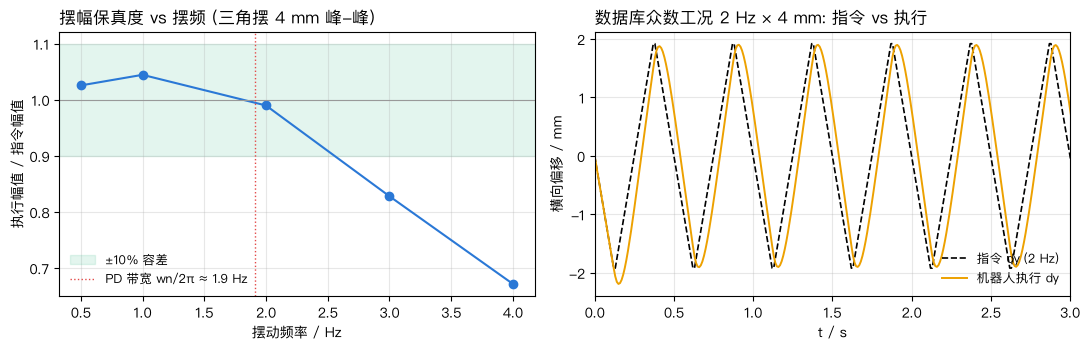

In [4]:
df = pd.DataFrame(sweep_rows)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(df["f/Hz"], df["幅值比"], "o-", color="#2a78d6")
ax[0].axhline(1.0, color="0.6", lw=0.8)
ax[0].axhspan(0.9, 1.1, color="#1baf7a", alpha=0.12, label="±10% 容差")
ax[0].axvline(12/(2*np.pi), color="#e34948", ls=":", lw=1,
              label="PD 带宽 wn/2π ≈ 1.9 Hz")
ax[0].set_xlabel("摆动频率 / Hz")
ax[0].set_ylabel("执行幅值 / 指令幅值")
ax[0].set_title("摆幅保真度 vs 摆频 (三角摆 4 mm 峰-峰)", loc="left")
ax[0].legend(frameon=False, fontsize=9)
tr = tracks[2.0]
ax[1].plot(tr["t"], tr["dy_cmd"]*1e3, "k--", lw=1.2, label="指令 dy (2 Hz)")
ax[1].plot(tr["t"], tr["dy_act"]*1e3, color="#eda100", lw=1.4,
           label="机器人执行 dy")
ax[1].set_xlabel("t / s")
ax[1].set_ylabel("横向偏移 / mm")
ax[1].set_title("数据库众数工况 2 Hz × 4 mm: 指令 vs 执行", loc="left")
ax[1].legend(frameon=False, fontsize=9)
ax[1].set_xlim(0, 3)
for a in ax:
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. 机器人执行摆动 → 热场: 理想 vs 执行的熔池差异

把实际 TCP 轨迹经 `RobotExecutedWeave` 适配器注入 `GoldakFDM` — 它只要求
`offset(t)` / `amplitude_m` / `frequency_Hz`, 不区分解析波形与采样序列;
`amplitude_m > 0` 自动切换全宽网格。三个热场运行, 工艺均为数据库中位
(`process=db_median solver=fine`), 热源功率逐步再归一化保证能量一致,
熔池差异纯粹来自轨迹:

| 运行 | 热源横向运动 |
|---|---|
| 理想·三角摆 | `weave=triangle` 逐字执行 (场景 notebook 同款) |
| 机器人执行·三角摆 | §3 中 2 Hz 跟踪仿真的实际轨迹 |
| 机器人执行·波形 1 | 摆动库梯形停留波形的实际轨迹 (换向更陡, 畸变更大) |

In [5]:
from welding_dynamics import RobotExecutedWeave

# 机器人执行 pattern1 (梯形摆); 三角摆 2 Hz 复用 §3 的跟踪结果
w_p1 = WEAVES["pattern1"]
t_p1, tip_p1, _, err_p1 = arm.track_path(p_ref_fun(w_p1), T_TRACK)
print(f"pattern1 跟踪: 三维 RMS {1e3*np.sqrt((err_p1**2).mean()):.2f} mm")

rw_tri = RobotExecutedWeave.from_tracking(
    tracks[2.0]["t"], tracks[2.0]["tip"], P0, V_WELD,
    frequency_Hz=2.0, label="机器人执行·三角摆")
rw_p1 = RobotExecutedWeave.from_tracking(
    t_p1, tip_p1, P0, V_WELD, frequency_Hz=2.0, label="机器人执行·波形1")

RUNS = [("理想·三角摆",      WEAVES["triangle"]),
        ("机器人执行·三角摆", rw_tri),
        ("机器人执行·波形1",  rw_p1)]
pools, rows = {}, []
for name, wv in RUNS:
    g = instantiate(cfg.goldak, Q=Q_ARC, weave=wv)      # weave 换成执行轨迹
    g.run(t_end=cfg.run.goldak.t_end, x_start=cfg.run.goldak.x_start)
    L, W, D = g.pool_size()
    pools[name] = g
    rows.append({"运行": name, "摆动": wv.describe(),
                 "L/mm": L, "W/mm": W, "D/mm": D,
                 "T_max/K": float(g.peak.max())})
pd.DataFrame(rows).round(1).set_index("运行")

pattern1 跟踪: 三维 RMS 0.93 mm


,摆动,L/mm,W/mm,D/mm,T_max/K
运行,,,,,
理想·三角摆,三角(直线摆) 2 Hz × 4 mm,18.4,11.2,4.8,5745.1
机器人执行·三角摆,机器人执行·三角摆 (501 采样) 2 Hz × 实际 4.09 mm,18.4,11.2,4.8,5687.4
机器人执行·波形1,机器人执行·波形1 (501 采样) 2 Hz × 实际 5.50 mm,17.6,11.2,4.8,5316.7


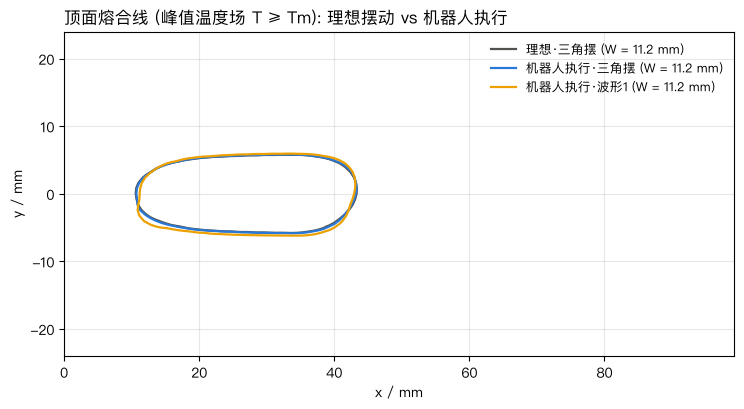

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for (name, _), color in zip(RUNS, ["#52514e", "#2a78d6", "#eda100"]):
    g = pools[name]
    ax.contour(g.x*1e3, g.y*1e3, g.peak[:, :, 0].T,
               levels=[float(g.Tm)], colors=[color], linewidths=1.6)
    W = dict(zip([r["运行"] for r in rows],
                 [r["W/mm"] for r in rows]))[name]
    ax.plot([], [], color=color, lw=1.6, label=f"{name} (W = {W:.1f} mm)")
ax.set_xlabel("x / mm")
ax.set_ylabel("y / mm")
ax.set_title("顶面熔合线 (峰值温度场 T ≥ Tm): 理想摆动 vs 机器人执行", loc="left")
ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 5. 结论

1. **运动学上全部平凡** — 26 mm 焊缝 + ±2 mm 摆动包络: 关节行程 82 mrad,
   速度需求 ≤ 4.6 deg/s (pattern1 最陡), IK 残差亚微米。可达性不构成约束。
2. **动态可执行性止步于控制带宽** — 三角摆 4 mm 峰-峰: ≤ 2 Hz 幅值比
   0.99–1.04 (±5% 内), 3 Hz 降到 0.83, 4 Hz 只剩 0.67, 横向 RMS 从 0.10 mm
   (0.5 Hz) 涨到 0.99 mm (4 Hz)。**数据库众数工况 2 Hz × 4 mm 恰好可执行**;
   要覆盖数据库上沿 3–4 Hz 需提高 PD 带宽 (`wn`) 或加前馈力矩。
3. **摆动库梯形波形按原样下发不可行** — pattern1 的停留→横移换向太陡,
   执行行程冲到 5.50 mm (指令 4.0 mm, **超调 +37%**), 跟踪 RMS 0.93 mm。
   部署前需限加速度重规划 (或降摆频)。
4. **热场对轨迹误差确实不敏感** (印证 §1 的预期) — 机器人执行三角摆与
   理想摆动的熔池在 dx = 0.8 mm 下不可区分 (L/W/D 同为 18.4/11.2/4.8 mm,
   T_max 差 1%); 连波形 1 的 +37% 超调也只让 T_max 降 7% (5745→5317 K)、
   L 缩 0.8 mm。**部署风险在工艺侧 (高摆频幅值不足、波形超调), 不在
   熔池畸变** — 这正是"机器人执行"环节值得在工艺规划阶段仿真的原因:
   问题在轨迹保真度上暴露, 远早于在焊缝质量上暴露。


## 相关

- **库侧新增**: `SixDofArm.track_path(p_ref_fun, t_end, ...)` — 跟踪任意
  三维参考轨迹 (焊缝跟踪 `seam_tracking` 是它的直线特例);
  `weave.RobotExecutedWeave` — 把跟踪仿真的 TCP 轨迹包成 `GoldakFDM`
  可用的摆动对象 (`from_tracking(t, tip, p0, v)`)。
- **CLI**: 模块 7b 演示 `uv run welding-sim-vi` (m7b_robot6_vi.png);
  热场命令行等价 `uv run welding-sim-3d process=db_median weave=triangle solver=fine`
  (理想摆动 — 机器人执行版本目前仅 notebook 流程)。
- **交互式三维渲染** 与五个典型工况总览: `welding_scenarios_interactive_demo.ipynb`。
- **可扩展方向**: 立/仰焊位置 (`track_path(R_ref=...)` 改焊枪姿态,
  `GoldakFDM` 需相应改重力对流假设 — 现模型无对流, 位置只影响机器人侧);
  提高 PD 带宽 (`wn`) 或加前馈力矩以支持 >2 Hz 摆频; 多道焊 (逐道偏移
  `P0` 重复本流程)。